<a href="https://colab.research.google.com/github/SagiMeir/Simulations4Beginners/blob/Ronny/Copy_of_sim4beginners.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MAIN**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

sns.set_theme(style="ticks", rc={'axes.labelsize': 14})

In [ ]:
x: int = 5 ** (-10)
# hbar is in J * s
hbar: float = 1.05457182 * (10**(-34))
omega: float = (50 * (10**(-3)) * (1.6 * (10**(-19))))/hbar

# omega in hrz
print("Omega (in Hz): " , omega)

# Calculation of mass
mass: float = 6.6335209 * (10**(-26))
print("Mass (in kg): " , mass)

# Energy in J
J: float = 0.5 * (x * omega) ** 2 * mass
print("\nEnergy (in Joules): " , J)

# Energy in eV
eV: float = (6.242 ** (-18)) * J
print("Energy (in eV): " , eV)

Omega (in Hz):  75860172330415.58
Mass (in kg):  6.6335209e-26

Energy (in Joules):  2.0014358253114444e-12
Energy (in eV):  9.671947074605484e-27


In [ ]:
from typing import Optional
import numpy as np
import pandas as pd
from scipy.constants import Boltzmann as BOLTZMANN
from scipy.constants import hbar

class Simulation:

    def __init__( self,
                 dt:float,
                 temp:float = 298,
                 Nsteps:int = 0,
                 R:Optional[np.ndarray] = None,
                 mass:Optional[float] = None,
                 kind:Optional[list] = None,
                 p:Optional[np.ndarray] = None,
                 F:Optional[np.ndarray] = None,
                 U:Optional[float] = None,
                 K:Optional[float] = None,
                 seed:Optional[int] = 937142,
                 ftype:str = "Harm",
                 step:int = 0,
                 printfreq:int = 1000,
                 xyzname:str = "sim.xyz",
                 fac:float = 1.0,
                 outname:str = "sim.log",
                  dim: int = 3,
                 gamma:float = None,
                  beads: int = None,
                 ) -> None:
        """
        Parameters
        ----------
        dt : float
            Simulation time step.

        temp: float
            The temperature.

        Nsteps : int, optional
            Number of steps to take. The default is 0.

        R : numpy.ndarray, optional
            Particles' positions, Natoms x 3 array. The default is None.

        mass : float, optional
            Particles' masses, Natoms x 1 array. The default is None.

        kind : list of str, optional
            Natoms x 1 list with atom type for printing. The default is None.

        p : numpy.ndarray, optional
            Particles' momenta, Natoms x 3 array. The default is None.

        F : numpy.ndarray, optional
            Particles' forces, Natoms x 3 array. The default is None.

        U : float, optional
            Potential energy . The default is None.

        K : float, optional
            Kinetic energy. The default is None.

        seed : int, optional
            Big number for reproducible random numbers. The default is 937142.

        ftype : str, optional
            String to call the force evaluation method. The default is None.

        step : INT, optional
            Current simulation step. The default is 0.

        printfreq : int, optional
            PRINT EVERY printfreq TIME STEPS. The default is 1000.

        xyzname : TYPE, optional
            DESCRIPTION. The default is "sim.xyz".

        fac : float, optional
            Factor to multiply the positions for printing. The default is 1.0.

        thermo_type: str, optional
            String to call the thermostating evaluation method. The default is None.

        outname : TYPE, optional
            DESCRIPTION. The default is "sim.log".

        Returns
        -------
        None.
        """

        #general
        self.printfreq = printfreq
        self.xyzfile = open( xyzname, 'w' )
        self.outfile = open( outname, 'w' )

        #simulation
        self.dim = dim
        self.gamma = gamma
        self.temp = temp
        self.Nsteps = Nsteps
        self.dt = dt
        self.seed = seed
        self.step = step
        self.fac = fac
        self.beads = beads

        #system
        if R is not None:
            self.R = R
            self.mass = mass
            self.kind = kind
            self.Natoms = self.R.shape[0]
            # self.mass_matrix = np.array( [self.mass,]*3 ).transpose()
        else:
            self.R = np.zeros( (1,3) )
            self.mass = 1.6735575E-27 # H mass in kg as default
            self.kind = ["H"]
            self.Natoms = self.R.shape[0]
            # self.mass_matrix = np.array( [self.mass,]*3 ).transpose()
        if p is not None:
            self.p = p
            self.K = K
        else:
            self.p = np.zeros( (self.Natoms,3) )
            self.K = 0.0

        if F is not None:
            self.F = F
            self.U = U
        else:
            self.F = np.zeros( (self.Natoms,3) )
            self.U = 0.0

        if beads is not None:
          self.beads = beads
          self.R_beads = np.array([Natoms, 3, self.beads])
          self.p_beads = np.array([Natoms, 3, self.beads])
          self.omegaP = ((np.sqrt(self.beads)) * BOLTZMAN * temp)/h_bar
          self.PIMD_xyz = [open(xyzname +'_bead'+ str(bead) + ".xyz", "w") for bead in range(beads)]

        #set seed
        np.random.seed( self.seed )

        #check force type
        if ( ftype == "Harm" or ftype == "Anharm"):
            self.ftype = "eval" + ftype
        else:
            raise ValueError("Wrong ftype value - use Harm or Anharm.")


    def __del__( self ) -> None:
        """
        THIS IS THE DESCTRUCTOR. NOT USUALLY NEEDED IN PYTHON.
        JUST HERE TO CLOSE THE FILES.
        Returns
        -------
        None.
        """
        self.xyzfile.close()
        self.outfile.close()

    def evalForce( self, **kwargs ) -> None:
        """
        THIS FUNCTION CALLS THE FORCE EVALUATION METHOD, BASED ON THE VALUE
        OF FTYPE, AND PASSES ALL OF THE ARGUMENTS (WHATEVER THEY ARE).
        Returns
        -------
        None. Calls the correct method based on self.ftype.
        """
        getattr(self, self.ftype)(**kwargs)

    def dumpThermo( self ) -> None:
        """
        THIS FUNCTION DUMPS THE ENERGY OF THE SYSTEM TO FILE.
        Parameters
        ----------
        R : numpy.ndarray
            Natoms x 3 array with particle coordinates.
        step : int
            Simulation time step.
        file : _io.TextIOWrapper
            File object to write to. Created using open() in main.py
        Returns
        -------
        None.
        """
        if( self.step == 0 ):
            self.outfile.write( "step K U E \n" )

        # Ensure U, K, and E are scalar values before formatting
        U_scalar = self.U.item() if isinstance(self.U, np.ndarray) else self.U
        K_scalar = self.K.item() if isinstance(self.K, np.ndarray) else self.K
        E_scalar = self.E.item() if isinstance(self.E, np.ndarray) else self.E


        self.outfile.write( str(self.step) + " " \
                          + "{:.6e}".format(K_scalar) + " " \
                          + "{:.6e}".format(U_scalar) + " " \
                          + "{:.6e}".format(E_scalar) + "\n" )

        self.outfile.flush()

    def dumpXYZ( self ) -> None:
        """
        THIS FUNCTION DUMP THE COORDINATES OF THE SYSTEM IN XYZ FORMAT TO FILE.
        Parameters
        ----------
        R : numpy.ndarray
            Natoms x 3 array with particle coordinates.
        step : int
            Simulation time step.
        file : _io.TextIOWrapper
            File object to write to. Created using open() in main.py
        Returns
        -------
        None.
        """

        self.xyzfile.write( str( self.Natoms ) + "\n")
        self.xyzfile.write( "Step " + str( self.step ) + "\n" )

        for i in range( self.Natoms ):
            self.xyzfile.write( self.kind[i] + " " + \
                              "{:.6e}".format( self.R[i,0]*self.fac ) + " " + \
                              "{:.6e}".format( self.R[i,1]*self.fac ) + " " + \
                              "{:.6e}".format( self.R[i,2]*self.fac ) + "\n" )

        self.xyzfile.flush()

    def dumpXYZ_PIMD(self) -> None:
       for bead in range(self.beads):
          self.PIMD.xyz.write[bead]
          self.PIMD.xyz.write[bead]

        for i in range( self.Natoms ):
            self.xyzfile.write( self.kind[i] + " " + \
                              "{:.6e}".format( self.R_beads[i,0,beads]*self.fac ) + " " + \
                              "{:.6e}".format( self.R_beads[i,1,beads]*self.fac ) + " " + \
                              "{:.6e}".format( self.R_beads[i,2,beads]*self.fac ) + "\n" )


    def readXYZ( self, inpname:str ) -> None:
        """
        THIS FUNCTION READS THE INITIAL COORDINATES IN XYZ FORMAT.
        Parameters
        ----------
        inpname : str
                xyz input file to read

        Returns
        -------
        None.
        """

        df = pd.read_csv( inpname, sep=r"\s+", skiprows=2, header=None )

        self.kind = df[ 0 ]
        self.R = df[ [1,2,3] ].to_numpy()
        self.Natoms = self.R.shape[0]


        ################################################################
        ################## NO EDITING ABOVE THIS LINE ##################
        ################################################################

    def CalcKinE( self ):
        """
        THIS FUNCTIONS EVALUATES THE KINETIC ENERGY OF THE SYSTEM.
        Returns
        -------
        None. Sets the value of self.K.
        """
        self.K = (self.p**2).sum()/(2*self.mass)

    def sampleMB( self, removeCM=True ):
        """
        THIS FUNCTIONS SAMPLES INITIAL MOMENTA FROM THE MB DISTRIBUTION.
        IT ALSO REMOVES THE COM MOMENTA, IF REQUESTED.
        Parameters
        ----------
        removeCM : bool, optional
            Remove COM velocity or not. The default is True.
        Returns
        -------
        None. Sets the value of self.p.
        """
        ################################################################
        ##################### YOUR CODE GOES HERE ######################
        ################################################################
        sigma = np.sqrt(self.mass * BOLTZMANN * self.temp)
        self.p = np.random.normal(0.0, sigma, size=(self.Natoms, self.dim))
        if self.beads is not none:
          self.p_beads = np.random.normal(0.0, sigma, size=(self.Natoms, self.dim, self.beads))

        if removeCM:
          p_cm = self.p.mean(axis=0)
          self.p -= p_cm

    def evalF_spring( self, omega:float ):
      for j in beads:
        sum_deltax  = (np.sum(self.R[:, :, (j + 1) % beads] - self.R[:, :, j]))**2
        self.E_spring = np.sum(self.mass * omega**2) * sum_deltax
        self.F_spring = - (self.mass * (omegaP**2)) * (2 * self.R_beads[:, :, j] - self.R_beads[:, :, (j + 1) % beads] - self.R_beads[:, :, j] * (-1))

    def evalHarm( self, omega:float ):
        """
        THIS FUNCTION EVALUATES THE POTENTIAL AND FORCE FOR A HARMONIC TRAP.
        Parameters
        ----------
        omega : float
            The frequency of the trap.
        Returns
        -------
        None. Sets the value of self.F and self.U
        """

        self.U = (self.mass/2) * (omega**2) * np.sum(self.R**2)
        self.F = (self.mass * omega**2 * self.R) * (-1)

    def VVstep( self, **kwargs ):
        """
        THIS FUNCTIONS PERFORMS ONE VELOCITY VERLET STEP.
        Returns
        -------
        None. Sets self.R, self.p.
        """

        self.p = self.p + self.dt/2 * self.F
        self.R = self.R + self.dt * (self.p/self.mass)
        self.evalForce(**kwargs)
        self.p = self.p + self.dt/2 * self.F

    def VVstep_NVT(self, **kwargs):

      gamma = self.gamma
      m = self.mass
      dim = self.dim
      kBT = BOLTZMAN * self.temp
      dt = self.dt

      exp_fac = np.exp(-self.gamma * self.dt / 2)
      self.sigma = np.sqrt(m * kBT * (1 - np.exp(-1 * self.gamma * dt)))

      self.xi1 = np.random.normal(0.0, 1.0, size=self.p.shape)
      if dim < 3:
          self.xi1[:,dim:] = np.zeros(shape = self.p.shape)[:,dim:]
      self.p = exp_fac * self.p + self.sigma * self.xi1

      self.VVstep(**kwargs)

      self.xi2 = np.random.normal(0.0, 1.0, size=self.p.shape)
      if dim < 3:
          self.xi2[:,dim:] = np.zeros(shape = self.p.shape)[:,dim:]
      self.p = exp_fac * self.p + self.sigma * self.xi2


    def VVStep_Pimd(self, **kwargs):

      self.p_beads = self.p_beads + self.dt/2 * (self.F_beads + self.F)
      self.R_beads = self.R_beads + self.dt * (self.p_beads/self.mass)
      self.evalForce(**kwargs)
      self.evalF_spring(**kwargs)
      self.p_beads = self.p_beads + self.dt/2 * (self.F_beads + self.F)

    def run( self, **kwargs ):
        """
        THIS FUNCTION DEFINES WHAT THE SIMULATION DOES, GIVEN AN INSTANCE OF
        THE SIMULATION CLASS. YOU WILL NEED TO:
            1. EVALUATE THE FORCES (USE evaluateForce() AND PASS A DICTIONARY
                                    WHICH ONLY CONTAINS THE PARAMETERS FOR THE
                                    FORCE EVALUATION METHOD).
            2. PROPAGATE FOR N TIME STEPS USING THE VELOCITY VERLET ALGORITHM.
            3. YOU WILL ALSO NEED TO PRINT THE COORDINATES AND ENERGIES EVERY
        PRINTFREQ TIME STEPS TO THEIR RESPECTIVE FILES, xyzfile AND outfile.
        Returns
        -------
        None.
        """

        self.evalForce(**kwargs)
        self.CalcKinE()
        self.E = self.K + self.U

        for step in range(self.Nsteps):
            self.step = step
            self.VVstep(**kwargs)
            self.CalcKinE()
            self.E = self.K + self.U

            if step % self.printfreq == 0:
              self.dumpXYZ()
              self.dumpThermo()

    def run_NVT(self, **kwargs):

      self.evalForce(**kwargs)
      self.sampleMB()
      self.CalcKinE()
      self.E = self.K + self.U

      for step in range(self.Nsteps):
        self.step = step
        self.VVstep_NVT(**kwargs)
        self.CalcKinE()
        self.E = self.K + self.U

        if step % self.printfreq == 0:
          self.dumpXYZ()
          self.dumpThermo()

      def run_pimd_NVE(self, **kwargs):
        self.R = self.R_beads
        self.p = self.p_beads
        self.evalForce(**kwargs)
        # before using evalForce, use those two def
        # divide force by beads

Several simulations

In [ ]:
for i, dt in enumerate(np.linspace(0.5e-15, 1.0e-15, 7)):

  mySim = Simulation(dt = dt, Nsteps = 10000, printfreq = 150, step = 0,  outname = "sim"+str(i)+".log", xyzname = "sim"+str(i)+".xyz")
  mySim.R = np.array([[5.0, 0.0, 0.0]])
  mySim.kind = ['Ar']
  mySim.Natoms = 1
  mySim.mass = 6.6335209e-26

  params = {"omega": 7.586017233041558e13}
  mySim.evalForce(**params)

  mySim.run(**params)

  from google.colab import files
  files.download("sim"+str(i)+".log")
  files.download("sim"+str(i)+".xyz")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# The Harmonic Oscillator

Figure 01

Max Δt with difference smaller than 0.1%: 8.333333333333334e-16


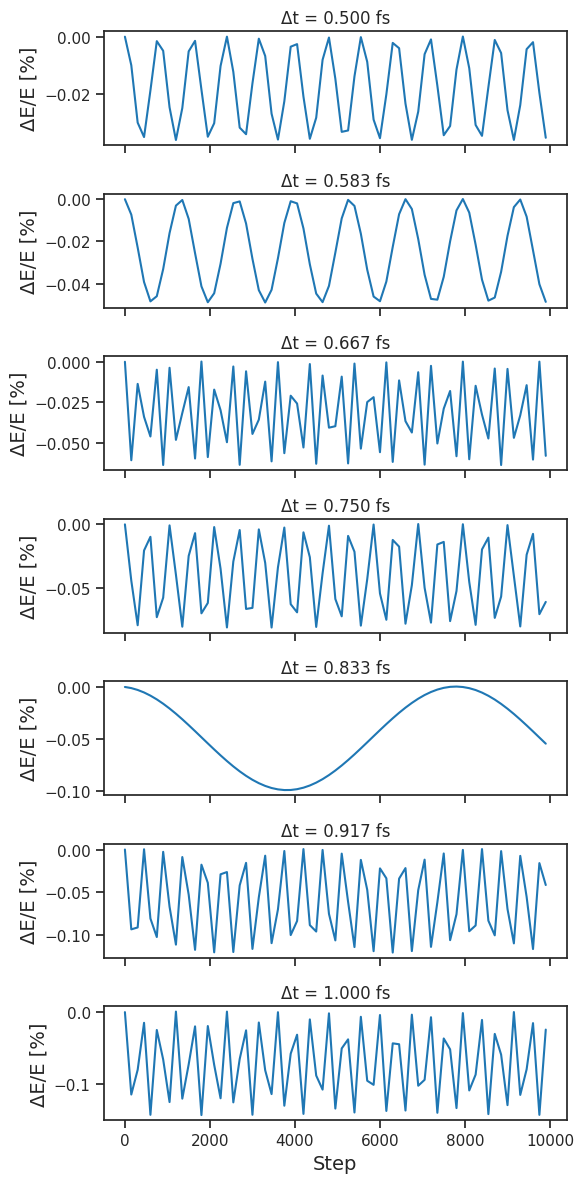

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", rc={'axes.labelsize': 14})

beforeDt: float = 0
found: bool = False

dt_values = np.linspace(0.5e-15, 1.0e-15, 7)

for i, dt in enumerate(dt_values):
    df = pd.read_csv(f"sim{i}.log", sep=r'\s+')

    energy = df["E"]
    initial_energy = energy.iloc[0]
    diff_percent = np.abs((energy - initial_energy) * 100 / initial_energy)
    max_diff = diff_percent.max()

    if max_diff >= 0.1 and not found:
        print("Max Δt with difference smaller than 0.1%:", beforeDt)
        found = True
        break

    beforeDt = dt

fig, ax = plt.subplots(len(dt_values), 1, figsize = (6, 12), sharex = True)

for i, dt in enumerate(dt_values):
    df = pd.read_csv(f"sim{i}.log", sep=r'\s+')
    step = df["step"]
    energy = df["E"]
    initial_energy = energy.iloc[0]
    delta_percent = (energy - initial_energy) * 100 / initial_energy

    ax[i].plot(step, delta_percent, color = 'tab:blue', linewidth = 1.5)
    ax[i].set_title(f"\u0394t = {dt * 1e15:.3f} fs")
    ax[i].set_ylabel("\u0394E/E [%]")


ax[-1].set_xlabel("Step")
plt.tight_layout()
plt.show()

Figure 02

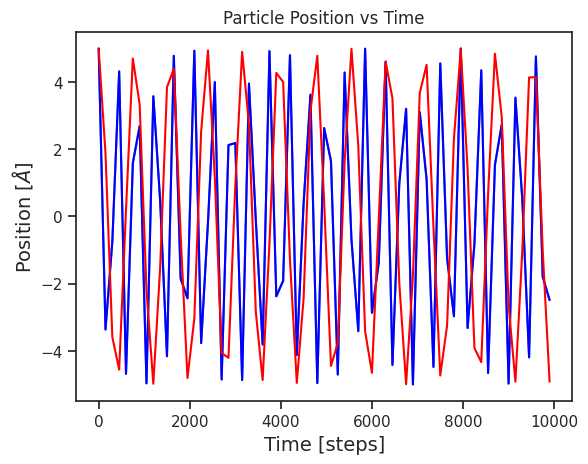

In [ ]:
import matplotlib.pyplot as plt
import math

time = []
posX = []

with open("sim3.xyz", "r") as f:
    while True:
        lines = [f.readline() for _ in range(3)]
        if not all(lines):
            break
        t = float(lines[1].strip().split()[1])
        x = float(lines[2].strip().split()[1])
        time.append(t)
        posX.append(x)

calc = []

for i in range(len(time)):
    calc.append(posX[0] * math.cos(omega * time[i] * dt))

plt.plot(time, posX, label="Position")
plt.xlabel("Time [steps]")
plt.ylabel(r"Position [$\AA$]")
plt.title("Particle Position vs Time")
plt.plot(time, posX, color = "blue", label = "Simulation movement")
plt.plot(time, calc, color = "red", label = "Theoreticsl movement")
plt.show()

Figure 03

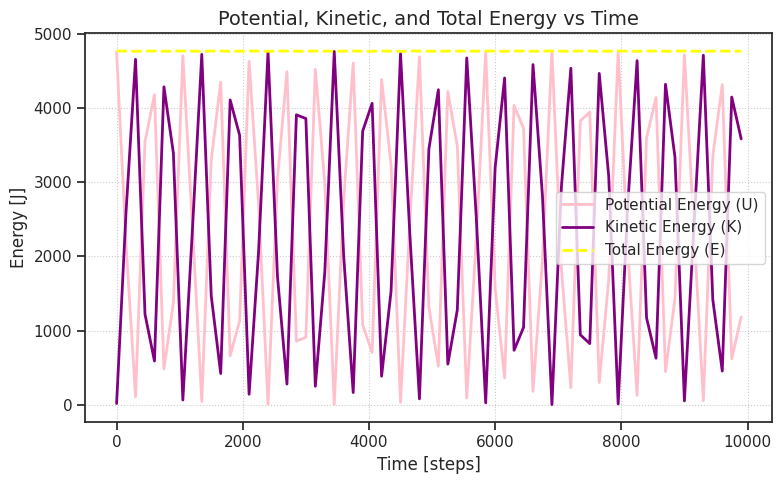

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style = "ticks",rc={'axes.labelsize':14},palette='tab10')

df = pd.read_csv("sim3.log", sep = r'\s+')

plt.figure(figsize = (8, 5))
plt.title("Potential, Kinetic, and Total Energy vs Time", fontsize = 14)
plt.xlabel("Time [steps]", fontsize = 12)
plt.ylabel("Energy [J]", fontsize = 12)
plt.plot(df['step'], df['U'], label = "Potential Energy (U)", color = "pink", linewidth = 2)
plt.plot(df['step'], df['K'], label="Kinetic Energy (K)", color = "purple", linewidth = 2)
plt.plot(df['step'], df['E'], label = "Total Energy (E)", color = "yellow", linewidth = 2, linestyle = "--")
plt.legend(fontsize = 11)
plt.grid(True, linestyle = ":", linewidth = 0.8)
plt.tight_layout()
plt.show()

Figure 4

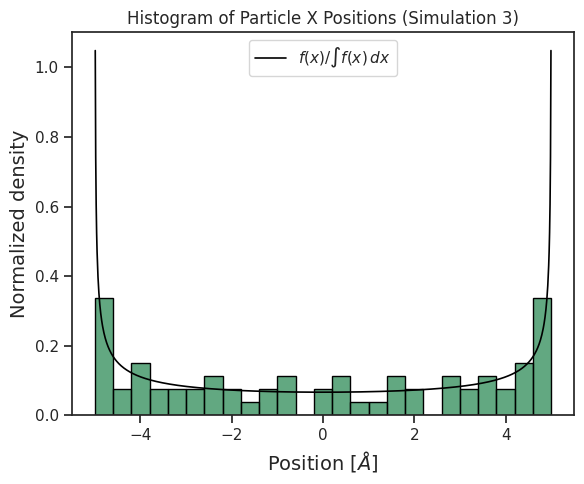

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks", rc={"axes.labelsize": 14}, palette="tab10")

omega = 75860172330415.58
x = np.linspace(-4.99, 4.99, 1000)
fx = 1/(omega * np.sqrt((5**2) - (x**2)))
s = np.trapezoid(fx, x)
fx_norm = fx / s

posX = []
with open("sim3.xyz") as f:
  while True:
      f.readline()
      comment_line = f.readline()
      if not comment_line:
          break

      line = f.readline()
      if not line:
          break

      fields = line.strip().split()
      if len(fields) >= 2:
            posX.append(float(fields[1]))

  plt.figure(figsize=(6, 5))
  sns.histplot(posX, bins=25, color='seagreen', edgecolor='black', stat='density')
  plt.plot(x, fx_norm, color='black', linewidth=1.2, label=r"$f(x)/\int f(x)\,dx$")
  plt.xlabel(r"Position [$\AA$]")
  plt.ylabel("Normalized density")
  plt.title("Histogram of Particle X Positions (Simulation 3)")
  plt.legend()
  plt.tight_layout()
  plt.show()

Figure 05

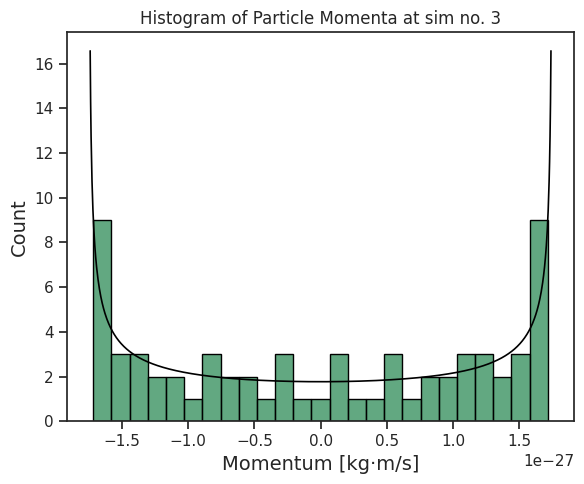

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", rc={"axes.labelsize": 14}, palette="tab10")

omega = 7.586017233041558e13
p_vals = np.linspace(-1.74 * 1e-27, 1.74 * 1e-27, 1000)
fx = 1 / (omega * np.sqrt((1.75e-27**2) - (p_vals**2)))
s = np.trapezoid(fx, p_vals)
fx_norm = fx / s

positions = []
times = []
mass = 6.6335209e-26

positions = []
times = []
with open("sim3.xyz", "r") as f:
  while True:
      lines = [f.readline() for _ in range(3)]
      if not all(lines):
          break
      try:
          t = float(lines[1].strip().split()[1])
          x = float(lines[2].strip().split()[1])
          times.append(t)
          positions.append(x)
      except (IndexError, ValueError):
          continue

positions = np.array(positions)
times = np.array(times)

unique_mask = np.diff(times, prepend=np.nan) > 0
positions = positions[unique_mask]
times = times[unique_mask]

velocities = np.gradient(positions, times)
momenta = mass * velocities

plt.figure(figsize=(6, 5))


plt.plot(p_vals, fx_norm * len(momenta) * (np.max(momenta) - np.min(momenta)) / 25, color='black', linewidth=1.2, label=r"$f(p)$ Scaled to Count")
sns.histplot(momenta, bins=25, color='seagreen', edgecolor='black')
plt.xlabel("Momentum [kg·m/s]")
plt.ylabel("Count")
plt.title("Histogram of Particle Momenta at sim no. 3")
plt.tight_layout()
plt.show()

# NVT Harmonic Oscillator

Simulations for gamma

In [ ]:
mySim = Simulation(dt = 8.333333333333334e-16, dim = 1, Nsteps = 10000, printfreq = 150, step = 0,  outname = "sim_NVT.log", xyzname="sim_NVT.xyz", gamma = omega)
mySim.run_NVT(**{"omega": 75860172330415.58})

In [ ]:
mySim = Simulation(dt = 8.333333333333334e-16, dim = 1, Nsteps = 10000, printfreq = 150, step = 0,  outname = "sim_NVT1.log", xyzname="sim_NVT1.xyz", gamma = 0.0000001 * omega)
mySim.run_NVT(**{"omega": 75860172330415.58})

In [ ]:
mySim = Simulation(dt = 8.333333333333334e-16, dim = 1, Nsteps = 10000, printfreq = 150, step = 0,  outname = "sim_NVT2.log", xyzname="sim_NVT2.xyz", gamma = 10000000 * omega)
mySim.run_NVT(**{"omega": 75860172330415.58})

Ideal temperature

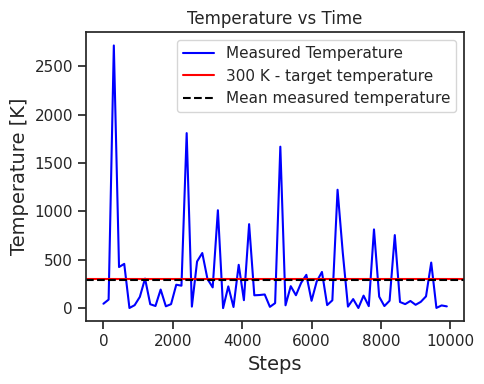

In [ ]:
t_target = 300
df = pd.read_csv("sim_NVT.log", sep = r'\s+')
temp = (2 * df["K"].values)/(BOLTZMANN)


fig, ax = plt.subplots(figsize = (5, 4))
ax.plot(df["step"], temp, color = 'blue', label = 'Measured Temperature')
ax.axhline(t_target, color = 'red', label = '300 K - target temperature')
ax.set_ylabel("Temperature [K]")
ax.set_xlabel("Steps")
ax.axhline(temp.mean(), color = 'black', linestyle = '--', label = 'Mean measured temperature')
ax.set_title("Temperature vs Time")
ax.legend()
plt.tight_layout()
plt.show()

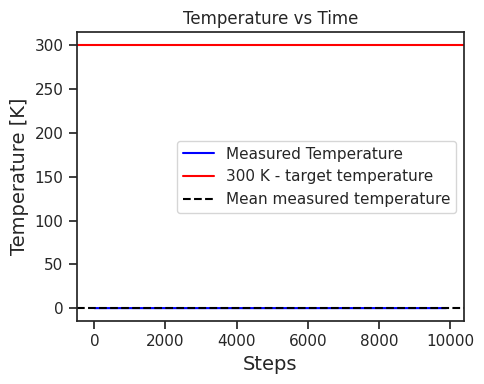

In [ ]:
t_target = 300
df = pd.read_csv("sim_NVT1.log", sep = r'\s+')
temp = (2 * df["K"].values)/(BOLTZMANN)


fig, ax = plt.subplots(figsize = (5, 4))
ax.plot(df["step"], temp, color = 'blue', label = 'Measured Temperature')
ax.axhline(t_target, color = 'red', label = '300 K - target temperature')
ax.set_ylabel("Temperature [K]")
ax.set_xlabel("Steps")
ax.axhline(temp.mean(), color = 'black', linestyle = '--', label = 'Mean measured temperature')
ax.set_title("Temperature vs Time")
ax.legend()
plt.tight_layout()
plt.show()

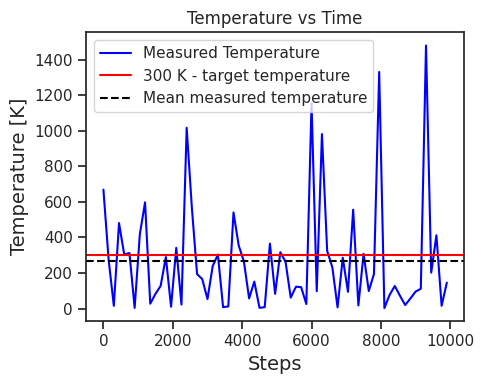

In [ ]:
t_target = 300
df = pd.read_csv("sim_NVT2.log", sep = r'\s+')
temp = (2 * df["K"].values)/(BOLTZMANN)


fig, ax = plt.subplots(figsize = (5, 4))
ax.plot(df["step"], temp, color = 'blue', label = 'Measured Temperature')
ax.axhline(t_target, color = 'red', label = '300 K - target temperature')
ax.set_ylabel("Temperature [K]")
ax.set_xlabel("Steps")
ax.axhline(temp.mean(), color = 'black', linestyle = '--', label = 'Mean measured temperature')
ax.set_title("Temperature vs Time")
ax.legend()
plt.tight_layout()
plt.show()